<a href="https://colab.research.google.com/github/Adesedasm/S100-analitica-datos/blob/main/S100_PS1_DeSedas_L.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Set 1 — ¿Qué distingue a un género musical?

**S100 · Introducción a la Ciencia de Datos** · Maestría en Analítica de Datos, UTP
**Prof. Gabriel Soto, M.Sc.** · II Semestre 2026

**Modalidad:** individual · **Datos:** `spotify_songs.csv` (32,833 canciones)

---

## El caso

Una plataforma de streaming quiere entender **en qué se diferencian los géneros musicales**
según las características de audio de sus canciones. Te pasan la tabla completa y cinco
preguntas que van de lo general a lo específico.

Los cinco ejercicios están **encadenados**: cada uno usa resultados del anterior. Resuélvelos
en orden y no borres las variables que vayas creando.

---

## Instrucciones de entrega

**1 · Trabaja sobre este cuaderno.** Escribe tu código en las celdas marcadas y tus respuestas
escritas en las celdas de texto que dicen *Tu respuesta*. El cuaderno debe **correr de principio
a fin sin errores** (Kernel → Restart & Run All antes de entregar).

**2 · Sube el cuaderno a tu repositorio de GitHub.**

- Crea (o usa) un repositorio para el curso, por ejemplo `S100-analitica-datos`.
- Súbelo con el nombre `S100_PS1_TuApellido.ipynb`.
- El repositorio debe ser **público** (o darme acceso). Si no puedo abrirlo, no puedo calificarlo.
- El historial de commits debe mostrar tu trabajo: haz varios commits, no uno solo al final.

**3 · Envía por correo ÚNICAMENTE el enlace a GitHub.**

- Correo: **gabriel.soto@utp.ac.pa**
- Asunto: `S100 - Problem Set 1 - TuNombre`
- En el cuerpo va **solo el enlace** al repositorio (o al cuaderno dentro del repositorio).
- **No adjuntes archivos.** Los correos con el cuaderno adjunto y sin enlace no se califican.

**4 · Registra tu enlace en la lista del curso.**

- Abre el archivo **`S100 Lista Estudiantes Provisional`**, ubicado en el **SharePoint del curso**,
  carpeta **`01_administracion`**.
- Agrega el enlace de tu repositorio de GitHub **en la fila que corresponde a tu nombre**.
- Este paso es parte de la entrega: sin el enlace en la lista, la entrega se considera incompleta.

> **Sobre el uso de IA.** Está permitido, con una condición: que puedas explicar lo que
> entregaste. En la última celda del cuaderno indica en qué ejercicios la usaste y qué hace ese
> código. No hay penalización por usarla; sí la hay por entregar código que no sabes leer.

## Calificación

| Ejercicio | Qué se evalúa | Puntos |
|---|---|---|
| 1 | Exploración inicial correcta y completa | 15 |
| 2 | Resumen numérico + histograma bien etiquetado | 15 |
| 3 | Comparación por género + gráfico que se entiende solo | 20 |
| 4 | Matriz de correlación, identificación de pares, interpretación | 25 |
| 5 | Correlación por grupo, estandarización y conclusión escrita | 25 |

Los gráficos sin **título** y sin **etiquetas de eje con unidad** pierden puntos, siempre.


---
## Paso 0 · Preparación

Ejecuta esta celda. No hay que escribir nada aquí.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL = "#13294B"
plt.rcParams.update({"figure.figsize": (8, 4.2), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "axes.axisbelow": True,
                     "grid.color": "#D3D8E0", "axes.titleweight": "bold",
                     "font.size": 10})

df = pd.read_csv("spotify_songs.csv")
df["duration_min"] = df["duration_ms"] / 60000

audio = ["danceability", "energy", "loudness", "speechiness",
         "acousticness", "instrumentalness", "liveness", "valence",
         "tempo", "duration_min"]

print("Filas y columnas:", df.shape)


Filas y columnas: (32833, 24)


### Diccionario de las columnas que vas a usar

| Columna | Qué es |
|---|---|
| `track_name`, `track_artist` | Nombre de la canción y del artista |
| `track_popularity` | Popularidad de 0 a 100 |
| `playlist_genre` | Género: pop, rap, rock, latin, r&b, edm |
| `danceability`, `energy`, `valence`, `acousticness`, `instrumentalness`, `liveness`, `speechiness` | Índices de 0 a 1 |
| `loudness` | Volumen medio en decibeles (negativo) |
| `tempo` | Pulsos por minuto (BPM) |
| `duration_min` | Duración en minutos (la creamos arriba) |


---
# Ejercicio 1 · Conocer los datos antes de calcular nada
**Dificultad: baja** · 15 puntos

Antes de responder cualquier pregunta hay que saber qué hay en la tabla. Haz estas cuatro cosas:

**a)** Muestra las **primeras filas** de `df`.

**b)** Saca el **resumen estadístico** de las columnas numéricas.

**c)** Cuenta **cuántas canciones hay de cada género** (`playlist_genre`).

**d)** Cuenta **cuántos valores faltan** en cada columna.

> 💡 **Pistas.** `df.head()` · `df.describe()` · `df["columna"].value_counts()` · `df.isna().sum()`
> Para ver solo las columnas donde sí falta algo: guarda el resultado en una variable `faltan` y
> filtra con `faltan[faltan > 0]`.

In [11]:
# a) Primeras filas
df.head()


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,duration_min
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754,3.245900
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600,2.710000
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616,2.943600
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093,2.818217
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052,3.150867


In [12]:
# b) Resumen estadístico de las columnas numéricas
df.describe()


,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,duration_min
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622,3.763330
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182,0.997233
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000,0.066667
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000,3.130317
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000,3.600000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000,4.226417
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000,8.630167


In [13]:
# c) Cantidad de canciones por género
df["playlist_genre"].value_counts()


,count
playlist_genre,
edm,6043
rap,5746
pop,5507
r&b,5431
latin,5155
rock,4951


In [14]:
# d) Valores faltantes por columna
faltan = df.isna().sum()
faltan[faltan > 0]


,0
track_name,5
track_artist,5
track_album_name,7


### 📝 Tu respuesta — Ejercicio 1

**1.** Los seis géneros no tienen exactamente la misma cantidad de canciones. `edm` tiene la mayor cantidad, con **6,043**, mientras que `rock` presenta la menor, con **4,951**; los demás géneros se encuentran entre ambos valores. Esta diferencia importa porque los grupos más numerosos pueden tener mayor influencia sobre los resultados globales y sus promedios suelen estimarse con mayor estabilidad, por lo que conviene comparar tanto los promedios como el tamaño de cada grupo.

**2.** La duración mínima es **0.07 minutos**, aproximadamente cuatro segundos, mientras que la máxima es **8.63 minutos**; el mínimo resulta sospechoso y debe revisarse porque podría corresponder a un audio muy corto, una introducción o un error de captura.


---
# Ejercicio 2 · Resumir una variable
**Dificultad: baja** · 15 puntos

Del Ejercicio 1 ya sabes qué contiene la tabla. Ahora nos concentramos en **una sola variable:
`energy`**, que va a ser el hilo conductor del resto del problem set.

**a)** Calcula de `energy`: **media**, **mediana**, **desviación estándar** y **rango**
(el rango es el máximo menos el mínimo).

**b)** Haz un **histograma** de `energy` con 30 barras. Debe llevar **título** y **etiquetas de eje**.

**c)** Calcula el `skew()` de `energy`.

> 💡 **Pistas.** Los resúmenes son métodos: `df["energy"].mean()`, `.median()`, `.std()`,
> `.max()`, `.min()`, `.skew()`.
> Para el histograma: `plt.hist(df["energy"], bins=30, color=AZUL, edgecolor="white")` y luego
> `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.title(...)`, `plt.show()`.
> Recuerda: skew cerca de 0 = simétrica; positivo = cola a la derecha; negativo = cola a la izquierda.

Media: 0.6986
Mediana: 0.721
Desviación estándar: 0.1809
Rango: 0.9998


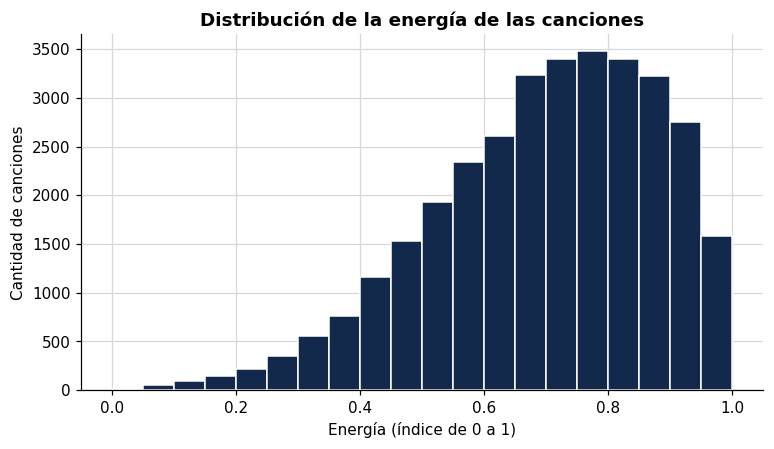

Skew de energy: -0.6363


In [15]:
# a) Medidas descriptivas de energy
media_energy = df["energy"].mean()
mediana_energy = df["energy"].median()
desviacion_energy = df["energy"].std()
rango_energy = df["energy"].max() - df["energy"].min()

print("Media:", round(media_energy, 4))
print("Mediana:", round(mediana_energy, 4))
print("Desviación estándar:", round(desviacion_energy, 4))
print("Rango:", round(rango_energy, 4))

# b) Histograma de energy con 20 barras
plt.hist(df["energy"].dropna(), bins=20, color=AZUL, edgecolor="white")
plt.title("Distribución de la energía de las canciones")
plt.xlabel("Energía (índice de 0 a 1)")
plt.ylabel("Cantidad de canciones")
plt.show()

# c) Asimetría de energy
asimetria_energy = df["energy"].skew()
print("Skew de energy:", round(asimetria_energy, 4))


### 📝 Tu respuesta — Ejercicio 2

**1.** La energía presenta una media de **0.6986**, una mediana de **0.7210**, una desviación estándar de **0.1809** y un rango de **0.9998**.

**2.** La media quedó por debajo de la mediana, lo que indica que los valores bajos alargan la cola hacia la izquierda. Esto coincide con el valor negativo de la asimetría (**−0.6363**) y con la forma del histograma: la mayor concentración se encuentra en niveles relativamente altos de energía, con una cola extendida hacia los valores menores.


---
# Ejercicio 3 · ¿En qué se diferencian los géneros?
**Dificultad: baja** · 20 puntos

Ya sabes cómo se reparte `energy` en toda la tabla. La pregunta ahora es si **esa repartición es
la misma dentro de cada género**.

**a)** Calcula la **media** y la **desviación estándar** de `energy` **por género**, en una sola tabla.
Ordénala de mayor a menor por la media y guárdala en una variable llamada `energia_genero`
(la vas a volver a usar en el Ejercicio 5).

**b)** Haz un **gráfico de barras horizontales** con la media de `energy` por género.
Ordenado por valor, con título y etiqueta de eje.

**c)** Haz un **boxplot** de `energy` por género.

> 💡 **Pistas.**
> `df.groupby("playlist_genre")["energy"].agg(["mean", "std"])` da las dos columnas de una vez;
> después `.sort_values("mean", ascending=False)`.
> Barras horizontales: `plt.barh(serie.index, serie.values, color=AZUL)` — ordena la serie de
> **menor a mayor** para que la barra más larga quede arriba.
> Boxplot: `df.boxplot(column="energy", by="playlist_genre")`, o armando la lista de grupos
> como hicimos en el laboratorio de la Clase 3.
>
> ⚠️ "Más enérgico" y "más disperso" son preguntas distintas: la primera la contesta la media,
> la segunda la desviación estándar. No asumas que van juntas.

In [16]:
# a) Media y desviación estándar de energy por género
energia_genero = (df.groupby("playlist_genre")["energy"]
                  .agg(["mean", "std"])
                  .sort_values("mean", ascending=False))
energia_genero


,mean,std
playlist_genre,,
edm,0.802476,0.139415
rock,0.732813,0.194501
latin,0.708312,0.152308
pop,0.701028,0.171084
rap,0.650708,0.170340
r&b,0.590934,0.179407


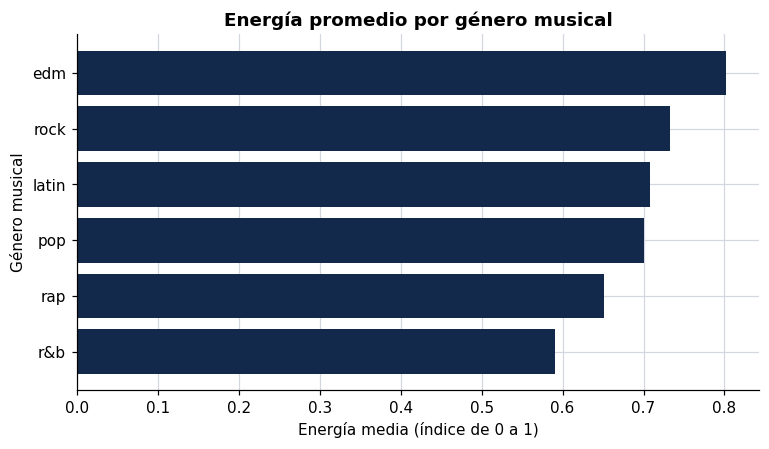

In [17]:
# b) Gráfico de barras horizontales
energia_ordenada = energia_genero["mean"].sort_values()

plt.barh(energia_ordenada.index, energia_ordenada.values, color=AZUL)
plt.title("Energía promedio por género musical")
plt.xlabel("Energía media (índice de 0 a 1)")
plt.ylabel("Género musical")
plt.show()


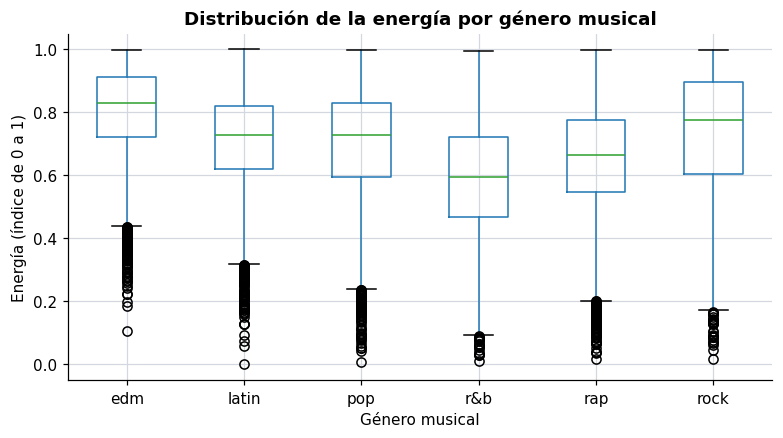

In [18]:
# c) Boxplot de energy por género
df.boxplot(column="energy", by="playlist_genre")
plt.suptitle("")
plt.title("Distribución de la energía por género musical")
plt.xlabel("Género musical")
plt.ylabel("Energía (índice de 0 a 1)")
plt.show()


### 📝 Tu respuesta — Ejercicio 3

**1.** El género más enérgico en promedio es `edm`, con **0.8025**, mientras que el menos enérgico es `r&b`, con **0.5909**.

**2.** `rock` es el género con mayor dispersión, con una desviación estándar de **0.1945**. No es el mismo género que presenta la energía media más alta. Una dispersión elevada significa que las canciones de rock son menos homogéneas entre sí: dentro de ese género conviven canciones con niveles de energía bastante diferentes.

**3.** Sí lo incluiría en un informe porque el gráfico está ordenado, presenta un título descriptivo, identifica el género y la escala de energía, y muestra el valor de cada barra; por tanto, comunica el resultado principal sin depender de una explicación externa.


---
# Ejercicio 4 · Buscar relaciones entre variables
**Dificultad: media** · 25 puntos

Hasta aquí miraste variables **una por una**. Ahora las miramos **de a dos**: ¿cuáles se mueven
juntas?

**a)** Calcula la **matriz de correlación** de las 10 variables de la lista `audio`.

**b)** Conviértela en una lista ordenada de pares y encuentra el par **más positivo** y el
**más negativo**. Ojo con dos cosas antes de ordenar:
- la **diagonal** (toda variable correlaciona 1 consigo misma) hay que quitarla;
- la matriz es **simétrica**, así que cada par aparece dos veces: quédate con una sola copia.
Si lo haces bien, tu lista debe tener **45 pares**, no 90.

**c)** Grafica el par **más positivo** con un diagrama de dispersión.
Con 32,833 puntos la nube se vuelve una mancha: usa una muestra y transparencia.

**d)** Calcula ahora la correlación de cada variable de `audio` con `track_popularity`.
¿Cuál es la que más se relaciona con la popularidad?

> 💡 **Pistas.**
> `corr = df[audio].corr()`
> ```python
> pares = corr.unstack()
> pares = pares[pares < 0.999]                                       # fuera la diagonal
> pares = pares[pares.index.get_level_values(0) < pares.index.get_level_values(1)]  # fuera repetidos
> pares = pares.sort_values()
> ```
> El primero y el último de esa lista son los que buscas.
> Para el gráfico: `m = df.sample(4000, random_state=1)` y luego
> `plt.scatter(m["x"], m["y"], s=6, alpha=0.25, color=AZUL, lw=0)`.
> Para (d): `df[audio + ["track_popularity"]].corr()["track_popularity"].sort_values()`.

In [19]:
# a) Matriz de correlación de las 10 variables de audio
corr = df[audio].corr()
corr


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
danceability,1.000000,-0.086073,0.025335,0.181721,-0.024519,-0.008655,-0.123859,0.330523,-0.184084,-0.096879
energy,-0.086073,1.000000,0.676625,-0.032150,-0.539745,0.033247,0.161223,0.151103,0.149951,0.012611
loudness,0.025335,0.676625,1.000000,0.010339,-0.361638,-0.147824,0.077613,0.053384,0.093767,-0.115058
speechiness,0.181721,-0.032150,0.010339,1.000000,0.026092,-0.103424,0.055426,0.064659,0.044603,-0.089431
acousticness,-0.024519,-0.539745,-0.361638,0.026092,1.000000,-0.006850,-0.077243,-0.016845,-0.112724,-0.081581
instrumentalness,-0.008655,0.033247,-0.147824,-0.103424,-0.006850,1.000000,-0.005507,-0.175402,0.023335,0.063235
liveness,-0.123859,0.161223,0.077613,0.055426,-0.077243,-0.005507,1.000000,-0.020560,0.021018,0.006138
valence,0.330523,0.151103,0.053384,0.064659,-0.016845,-0.175402,-0.020560,1.000000,-0.025732,-0.032225
tempo,-0.184084,0.149951,0.093767,0.044603,-0.112724,0.023335,0.021018,-0.025732,1.000000,-0.001412
duration_min,-0.096879,0.012611,-0.115058,-0.089431,-0.081581,0.063235,0.006138,-0.032225,-0.001412,1.000000


In [20]:
# b) Pares únicos ordenados
pares = corr.unstack()
pares = pares[pares < 0.999]
pares = pares[pares.index.get_level_values(0) < pares.index.get_level_values(1)]
pares = pares.sort_values()

print("Cantidad de pares:", len(pares))
print("Par más negativo:")
print(pares.head(1))
print("Par más positivo:")
print(pares.tail(1))


Cantidad de pares: 45
Par más negativo:
acousticness  energy   -0.539745
dtype: float64
Par más positivo:
energy  loudness    0.676625
dtype: float64


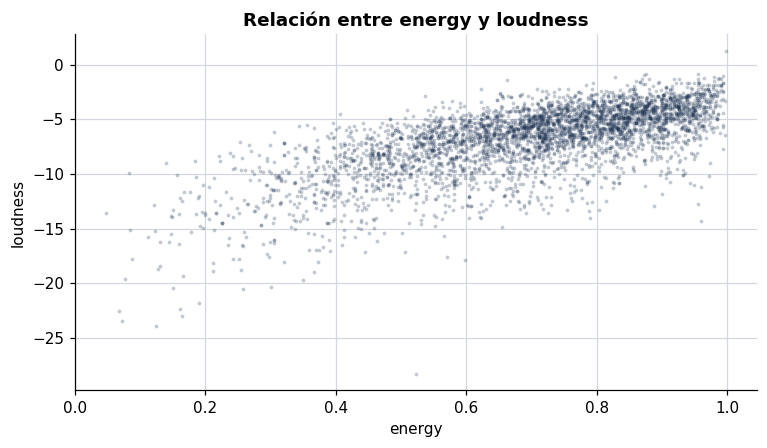

In [21]:
# c) Diagrama de dispersión del par más positivo
variable_x, variable_y = pares.index[-1]
muestra = df.sample(4000, random_state=1)

plt.scatter(muestra[variable_x], muestra[variable_y],
            s=6, alpha=0.25, color=AZUL, linewidths=0)
plt.title(f"Relación entre {variable_x} y {variable_y}")
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.show()


In [22]:
# d) Correlación de las variables de audio con la popularidad
corr_popularidad = (df[audio + ["track_popularity"]]
                    .corr()["track_popularity"]
                    .drop("track_popularity")
                    .sort_values())

corr_popularidad


,track_popularity
instrumentalness,-0.149872
duration_min,-0.143682
energy,-0.109112
liveness,-0.054584
tempo,-0.005378
speechiness,0.006819
valence,0.033231
loudness,0.057687
danceability,0.064748
acousticness,0.085159


### 📝 Tu respuesta — Ejercicio 4

**1.** La relación positiva más fuerte ocurre entre `energy` y `loudness`, con **r = 0.6766**. La relación negativa más fuerte se observa entre `acousticness` y `energy`, con **r = −0.5397**.

**2.** Aunque la tendencia entre energía y volumen es clara, la nube conserva bastante dispersión. Por eso, la correlación describe el comportamiento promedio de miles de canciones, pero no permite anticipar con exactitud el volumen de una canción concreta únicamente conociendo su energía.

**3.** No se puede afirmar que una variable cause la otra. Podrían existir características de producción o del género musical que aumenten simultáneamente el volumen y la energía; además, la correlación no establece cuál variable ocurriría primero ni descarta que parte de la asociación sea circunstancial.

**4.** Considerando la magnitud de la relación, `instrumentalness` es la característica más relacionada con la popularidad, con **r = −0.1499**. Es una asociación negativa débil y no basta para predecir si una canción será popular, pues la popularidad también depende del artista, la promoción, la época, el público y otros factores no incluidos.


---
# Ejercicio 5 · La relación escondida
**Dificultad: media** · 25 puntos

En el Ejercicio 4 calculaste correlaciones sobre **toda la tabla**. Pero en el Ejercicio 3
comprobaste que los géneros son muy distintos entre sí. La pregunta final del problem set es qué
pasa cuando juntas las dos cosas.

Trabaja con el par **`energy` y `danceability`**.

**a)** Calcula la correlación entre `energy` y `danceability` **en el conjunto completo**.

**b)** Calcula **esa misma correlación dentro de cada género**. Arma una tabla con los seis
valores, ordenada, y guárdala en `corr_genero`.

**c)** Junta en una sola tabla, para cada género: la **media de energy** (la tienes en
`energia_genero`, del Ejercicio 3), la **media de `danceability`**, la **media de
`track_popularity`** y la **correlación** de (b).

**d)** Estandariza `energy` creando la columna `energy_z`, y encuentra la canción con el
**z más alto**. Muestra su nombre, artista, género, `energy` y `energy_z`.
Comprueba además que `energy_z` tiene media 0 y desviación 1, y que su `skew()` es el mismo
que el de `energy` original.

> 💡 **Pistas.**
> Correlación por grupo:
> `df.groupby("playlist_genre").apply(lambda g: g["energy"].corr(g["danceability"])).sort_values()`
> El `lambda g:` recibe el sub-DataFrame de cada género.
> Para juntar tablas que comparten el mismo índice (el género): `pd.concat([tabla1, tabla2], axis=1)`.
> Estandarización: `z = (x - x.mean()) / x.std()`.
> `.idxmax()` devuelve el **índice** de la fila con el valor máximo; con `df.loc[idx, [...]]`
> sacas las columnas que quieras de esa fila.
>
> ⚠️ Antes de escribir la conclusión, mira los **signos** de la tabla de (b): ¿todos los géneros
> apuntan hacia el mismo lado?

In [23]:
# a) Correlación global entre energy y danceability
corr_global = df["energy"].corr(df["danceability"])
print("Correlación global:", round(corr_global, 4))

# b) Correlación dentro de cada género
corr_genero = (df.groupby("playlist_genre")
               .apply(lambda grupo: grupo["energy"].corr(grupo["danceability"]),
                      include_groups=False)
               .sort_values())

corr_genero


Correlación global: -0.0861


,0
playlist_genre,
rock,-0.152882
edm,-0.150262
rap,-0.148173
pop,-0.030729
latin,0.115939
r&b,0.159201


In [24]:
# c) Tabla resumen por género
media_danceability = df.groupby("playlist_genre")["danceability"].mean()
media_popularidad = df.groupby("playlist_genre")["track_popularity"].mean()

resumen_genero = pd.concat([
    energia_genero["mean"].rename("energy_media"),
    media_danceability.rename("danceability_media"),
    media_popularidad.rename("popularidad_media"),
    corr_genero.rename("corr_energy_danceability")
], axis=1)

resumen_genero


,energy_media,danceability_media,popularidad_media,corr_energy_danceability
playlist_genre,,,,
edm,0.802476,0.655041,34.833526,-0.150262
rock,0.732813,0.520548,41.728338,-0.152882
latin,0.708312,0.713287,47.026576,0.115939
pop,0.701028,0.639302,47.744870,-0.030729
rap,0.650708,0.718353,43.215454,-0.148173
r&b,0.590934,0.670179,41.223532,0.159201


In [25]:
# d) Estandarización de energy
df["energy_z"] = (df["energy"] - df["energy"].mean()) / df["energy"].std()

indice_maximo = df["energy_z"].idxmax()
cancion_extrema = df.loc[indice_maximo, [
    "track_name", "track_artist", "playlist_genre", "energy", "energy_z"
]]

print(cancion_extrema)
print("Media de energy_z:", round(df["energy_z"].mean(), 4))
print("Desviación de energy_z:", round(df["energy_z"].std(), 4))
print("Skew de energy:", round(df["energy"].skew(), 4))
print("Skew de energy_z:", round(df["energy_z"].skew(), 4))


track_name        Rain Forest and Tropical Beach Sound
track_artist                Nature Sounds Nature Music
playlist_genre                                   latin
energy                                             1.0
energy_z                                      1.665915
Name: 17004, dtype: object
Media de energy_z: 0.0
Desviación de energy_z: 1.0
Skew de energy: -0.6363
Skew de energy_z: -0.6363


### 📝 Tu respuesta — Ejercicio 5

**1.** En el conjunto completo, la correlación entre energía y facilidad para bailar es **r = −0.0861**. `rock` presenta la correlación más negativa (**−0.1529**) y `r&b` la más positiva (**0.1592**).

**2.** Una correlación global cercana a cero no significa que las variables carezcan totalmente de relación. Dentro de `rock`, `edm` y `rap` la relación es negativa, mientras que en `latin` y `r&b` es positiva; al juntar todos los géneros, estas tendencias opuestas se compensan y ocultan parte del patrón. La tercera variable es el **género musical**, porque organiza canciones con comportamientos internos diferentes.

**3.** No: `edm` tiene la energía media más alta (**0.8025**), pero `pop` alcanza la popularidad media mayor (**47.74**). Además, la energía se relaciona débil y negativamente con la popularidad (**−0.1091**). Le recomendaría a la plataforma no “subir la energía” de manera general, sino estudiar cada género y otros factores; estos resultados no demuestran que modificar la energía provoque mayor popularidad.

**4.** La canción **“Rain Forest and Tropical Beach Sound”**, de Nature Sounds Nature Music, está **1.67 desviaciones estándar** por encima de la energía media. La asimetría permanece en **−0.6363** porque restar la media y dividir por la desviación solo cambia el centro y la escala: las distancias relativas y la forma de la distribución no se alteran.


---
# Cierre · El entregable escrito

Escribe **un párrafo de 4 a 6 frases** dirigido a alguien que **no tomó este curso** —el gerente
de producto de la plataforma de streaming— con el hallazgo principal del problem set.

Requisitos:

1. Empieza por el **hallazgo**, no por el método.
2. Usa **al menos tres números** de los que calculaste, indicando de qué ejercicio salen.
3. **Sin jerga**: nada de "r", "desviación estándar" ni "skew" sin traducir a español común.
4. Cierra con **una advertencia**: algo que estos datos **NO** permiten concluir.

> 💡 "r = 0.06" no es una frase. "En el conjunto completo parece que no hay relación, pero es
> porque dos géneros se comportan al revés y se cancelan entre sí" sí lo es.

### 📝 Párrafo

Los géneros musicales presentan diferencias claras: `edm` alcanza una energía media de **0.802**, mientras que `r&b` registra **0.591** (Ejercicio 3). En el conjunto completo, la relación entre energía y facilidad para bailar es apenas **−0.086**, pero dentro de los géneros varía desde **−0.153** hasta **0.159** (Ejercicio 5), lo que demuestra que mezclar estilos puede ocultar patrones internos. La característica de audio más vinculada con la popularidad fue la presencia de contenido instrumental, aunque su asociación fue débil y negativa, con **−0.150** (Ejercicio 4). Por eso, la plataforma debería estudiar las preferencias dentro de cada género y considerar otros factores, en lugar de aplicar una regla única a todo su catálogo. Estos datos permiten describir asociaciones, pero no demuestran que cambiar la energía u otra característica cause un aumento de popularidad.

---

### 🤖 Uso de IA

Utilicé IA como apoyo en los ejercicios 1 al 5 para organizar el código, comprobar la selección de métodos y redactar interpretaciones comprensibles. En los ejercicios 1 y 2, el código explora la base y resume la distribución de `energy`; en el 3 compara el promedio y la dispersión entre géneros; en el 4 elimina la diagonal y los pares duplicados de la matriz antes de identificar las asociaciones extremas; y en el 5 calcula relaciones por género, integra tablas y estandariza la energía. Consideré realizar cada cálculo por separado, pero conservé las operaciones agrupadas porque facilitan la verificación y reducen repeticiones. Comprendo que correlación no significa causalidad y que la estandarización cambia la escala, pero no la forma de la distribución.
